# Wstępna Eksploracyjna Analiza Danych ze Steam
Celem tej sekcji jest ustalenie wstępnych wymagań wobec zbioru danych przed jego pełnym pobraniem ze Steam API.

W projekcie celem jest stworzenie algorytmu wykrywającego sentyment oceny gry, uwzględniając sarkzam.

Wytrenowanie skutecznego modelu będzie wymagało przekroju różnych opinii, z różnych gatunków gier, o różnych wymogach technicznych. Powody opinii negatywnej czy sarkastycznej mogą wynikać zarówno z problemów z fabułą i mechaniką gry, ale również z braku optymalizacji gry dla słabszego sprzętu. Algorytm wytrenowany wyłącznie na recenzjach najpopularniejszych gier mogłoby skutkować z tendencyjnością algorytmu i wysoką liczebnością klasy False Negative.

Dodatkowo zdaniem autora najpopularniejsze gry mogą częściej mieć problemy z optymalizacją niż z samą rozgrywką, niż przeciętna gra. Gracze chętniej spróbują zagrać w ciekawą grę, która jest niezoptymalizowana na ich sprzęt, z nadzieją, że twórca gry po pewnym czasie wypuści aktualizację, która ustabilizuje ilość klatek na sekundę na ich sprzęcie. Natomiast, jeśli gra jest dobrze zoptymalizowana ale nudna gra nigdy nie trafi do listy najpopularniejszych gier.

Osobnym wyzwaniem jest ilość opinii w języku polskim. Sarkazm jest zjawiskiem bardzo specficznym dla każdego języka, dlatego do trenowania modelu autor wybierze wyłącznie opinie w języku polskim. Tym sposobem autor będzie mógł na koniec podejrzeć wyniki algorytmu i samodzielnie ocenić jego poprawne funkcjonowanie. Ograniczenie językowe oznacza, że skupienie się wyłącznie na mało popularnych grach może skutkować trudnością z uzbieraniem odpowiedniej ilości opinii i znacznie większą ilością zapytań do Steam API.

Zważając na powyższe ograniczenia autor zamierza najpierw podzielić dużą populację najczęściej granych gier podzielić na grupy według ich kategorii oceny Steam, a następnie z każdej grupy losowo wybrać podobną liczbę gier, aby cały zbiór recenzji posiadał około **??** tysięcy opinii.

## Przegląd najpopularniejszych gier na platformie Steam

Steam ma przyjazne API dla scrapingu, jednak odnalezienie się w nim nie jest najprostsze. Nie ma punktu końcowego, z którego możnaby uzyskać listę najpopularniejszych gier z ilością opinii w języku polskim. Steam posiada listy 100 topowych gier wedle różnych projektów, ale na początku potrzebna jest dłuższa lista.

[SteamDB](https://steamdb.info/) jest darmową, niezależną bazą danych Steam. SteamDB po zalogowaniu pozwala na wyświetlenie list o wiele dłuższych niż 100 gier.

W celu wyboru odpowiednich gier autor kierował się [listą najpopularnieszych gier w maju 2026](https://steamdb.info/charts/?month=2026-05&sort=peak). Lista zawiera wszystkie gry, w które w szczytowym momencie maja 2026 grało co najmniej 100 osób. SteamDB zabrania scrapingu, dlatego autor ręcznie zapisał zawartość HTML strony w repozytorium.

In [144]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Otwórz plik html 
with open('../data/steamdb_all_time_peak.html', 'r', encoding='utf-8') as file:
  steamdb_html = file.read()
steamdb_html_soup = BeautifulSoup(steamdb_html, 'html.parser')
print(steamdb_html_soup)


<!DOCTYPE html>

<html lang="en">
<head>
<meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1.0, viewport-fit=cover" name="viewport"/>
<title>Steam Charts · Live Player Count Statistics in May 2026 · SteamDB</title>
<link href="https://shared.fastly.steamstatic.com/" rel="preconnect"/>
<link as="font" crossorigin="anonymous" href="/static/fonts/Inter-Regular.woff2?v=4.1" rel="preload" type="font/woff2"/>
<link as="font" crossorigin="anonymous" href="/static/fonts/Inter-Bold.woff2?v=4.1" rel="preload" type="font/woff2"/>
<link as="font" crossorigin="anonymous" href="/static/fonts/Inter-Italic.woff2?v=4.1" rel="preload" type="font/woff2"/>
<link href="/static/css/headcrab.css?v=97aeb4b2506e66f7" integrity="sha384-l660slBuZveyRNxdTuniZ819O7OdqIs2/gBijoib5q+xqkRBgZTFIzkij77Pa0tA" rel="stylesheet"/>
<link href="/static/css/charts.css?v=6fa7d7f292bd34c2" integrity="sha384-b6fX8pK9NMIdv+xzEg2H00csjI2KQAm8NWjB+aC3gcPgNDGuGqkXylJugZkB7YkN" rel="stylesheet"/>
<link href="h

In [17]:
# Podgląd nagłówków tabeli ze SteamDB
steamdb_html_thead = steamdb_html_soup.find('thead')
steamdb_headers = list(map(lambda th: th.get_text() ,steamdb_html_thead.find_all('th')))
print('Nagłówki tabeli SteamDB - ID gier nie jest widoczne jako tekst tabeli, ale jest dostępne w atrybutach.')
print(steamdb_headers)

Nagłówki tabeli SteamDB - ID gier nie jest widoczne jako tekst tabeli, ale jest dostępne w atrybutach.
['Rank', 'SteamDB.info', 'Name', 'Current', "May '26 Peak", 'All-Time Peak', ' ']


In [ ]:
# Podgląd zawartości tabeli ze SteamDB - data-appid zawiera ID gry ze Steam
steamdb_html_tbody = steamdb_html_soup.find('tbody').find_all('tr')
print(f'Znaleziono {len(steamdb_html_tbody)} gier.\n')
print(steamdb_html_tbody)

Znaleziono 4161 gier.

[<tr class="app" data-appid="578080" data-capsule="14f42ab797699a9c9f137fda66582d8776da4330/capsule_231x87.jpg">
<td>1.</td>
<td class="applogo text-left"><a aria-hidden="true" href="/app/578080/charts/" tabindex="-1"><img alt="" src="/static/img/applogo.svg"/></a></td>
<td><a class="b" href="/app/578080/charts/">PUBG: BATTLEGROUNDS</a></td>
<td data-sort="277031">277,031</td>
<td data-sort="822514">822,514</td>
<td data-sort="3257248">3,257,248</td>
<td class="add">+</td>
</tr>, <tr class="app" data-appid="2358720" data-capsule="b7f722ddd5e23503f598586aa3700dd4d827bb2d/capsule_231x87.jpg">
<td>2.</td>
<td class="applogo text-left"><a aria-hidden="true" href="/app/2358720/charts/" tabindex="-1"><img alt="" src="/static/img/applogo.svg"/></a></td>
<td><a class="b" href="/app/2358720/charts/">Black Myth: Wukong</a></td>
<td data-sort="7713">7,713</td>
<td data-sort="16286">16,286</td>
<td data-sort="2415714">2,415,714</td>
<td class="add">+</td>
</tr>, <tr class="a

In [98]:
steamdb_parsed = []

for tr in steamdb_html_tbody:
  steam_id = tr.get('data-appid')

  tds = tr.find_all('td')
  if len(tds) == 7:
    steam_name = tds[2].get_text()
    all_time_peak = int(tds[5].get('data-sort'))

  steamdb_parsed.append({
    'steam_id': steam_id,
    'name': steam_name,
    'all-time_peak': all_time_peak
  })

df_steamdb = pd.DataFrame(steamdb_parsed)
print(df_steamdb)

     steam_id                                  name  all-time_peak
0      578080                   PUBG: BATTLEGROUNDS        3257248
1     2358720                    Black Myth: Wukong        2415714
2     1623730                              Palworld        2101867
3         730                      Counter-Strike 2        1862531
4     2246340                  Monster Hunter Wilds        1384608
...       ...                                   ...            ...
4156  1988540  The Zachtronics Solitaire Collection            128
4157  3689850             Final War: Frozen Defense            128
4158  3515100                                  OCCT            127
4159  2505570                         Burger Shop 3            123
4160  2485190            MediBang Paint for Desktop            121

[4161 rows x 3 columns]


Przy potrzebnej wielkości populacji do uczenia maszynowego, planem jest skupienie się na grach, które mają co najmniej 100 opinii. W późniejszym etapie Steam będzie pozwalał na pobranie opinii w paczkach o maksymalnym rozmiarze 100 opinii. Dlatego, żeby nie generować zbyt wielu zapytań do Steam, celem analizy jest skupienie się na grach, które będą zwracać co najmniej jedną pełną paczkę. Ilość opinii zawsze będzie znacząco niższa od ilości graczy, dlatego dla uproszczenia poddane zostaną analizie gry o szczytowej popularności powyżej 5000 graczy.

In [139]:
df_steamdb_popular = df_steamdb[df_steamdb['all-time_peak'] > 5000]
df_steamdb_popular['total_reviews'] = np.nan
df_steamdb_popular['total_positive'] = np.nan
df_steamdb_popular['total_negative'] = np.nan
df_steamdb_popular['percent_positive'] = np.nan
df_steamdb_popular['review_score'] = np.nan
df_steamdb_popular['review_score_desc'] = ''
print(df_steamdb_popular)


print('\n\nZapisywanie do pliku CSV...')
stats_path = '../data/steam_stats.csv'
id_col_name = 'steam_id'

# Załadowanie listy istniejących ID - użyto set() bo ma złożoność czasową O(1)
if os.path.exists(stats_path):
  df_existing_stats = pd.read_csv(stats_path, usecols=[id_col_name])
  existing_ids = set(df_existing_stats[id_col_name].astype(str))
else:
  existing_ids = set()

new_apps = df_steamdb_popular[
    ~df_steamdb_popular[id_col_name].isin(existing_ids)
]

# Zapis nowych danych - jeśli plik nie istnieje dodatkowo zapisane nagłówki.
if new_apps.shape[0] > 0:
    header_required = not os.path.exists(stats_path)
    
    new_apps.to_csv(stats_path, mode='a', header=header_required, index=False)
    print(f'Dodano {len(new_apps)} nowych gier.')
else:
    print('Brak nowych gier.')

     steam_id                                  name  all-time_peak  \
0      578080                   PUBG: BATTLEGROUNDS        3257248   
1     2358720                    Black Myth: Wukong        2415714   
2     1623730                              Palworld        2101867   
3         730                      Counter-Strike 2        1862531   
4     2246340                  Monster Hunter Wilds        1384608   
...       ...                                   ...            ...   
1736   435120                      Rusty Lake Hotel           5038   
1737   418240  Shadow Tactics: Blades of the Shogun           5037   
1738   407130               Tank Mechanic Simulator           5022   
1739    21970                               R.U.S.E           5018   
1740   822240                            Animal Jam           5009   

      total_reviews  total_positive  total_negative  percent_positive  \
0               NaN             NaN             NaN               NaN   
1            

Dla powyższych gier zostaje przeprowadzony scraping z oficjalnych serwerów Steam. Dla każdej z gier potrzebna jest informacja o łącznej ilości opinii w języku polskim oraz średnim wyniku recenzji. Aby przypadkowo nie uruchomić ponownie ponad 1500 zapytań do Steam została dodana flaga `overwrite_stats`, która decyduje o tym, czy zostaną nadpisane informacje o recencjach dla gry, która już takie informacje posiada.

In [140]:
def get_game_review_stats(stats_path_output, overwrite_stats=False):
  try:
    df_apps = pd.read_csv(stats_path_output)
  except Exception:
    sys.exit('Ścieżka nie istnieje, spróbuj ponownie po utworzeniu pliku.')

  rate_limit_hits = 0
  max_rate_hits = 5
  initial_sleep = 2
  
  # Kopia do pracy
  df_apps_processing = df_apps.astype({'review_score_desc':str})
  
  # Jeśli nadpisujemy, zerujemy kolumny w kopii
  if overwrite_stats:
    df_apps_processing['total_reviews'] = np.nan
    df_apps_processing['total_positive'] = np.nan
    df_apps_processing['total_negative'] = np.nan
    df_apps_processing['percent_positive'] = np.nan
    df_apps_processing['review_score'] = np.nan
    df_apps_processing['review_score_desc'] = ''

  headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
  }
  params = {
    'json': 1,
    'purchase_type': 'all',
    'l': 'polish'
  }

  # Liczymy wiersze, które mają braki w 'total_reviews'
  missing_data_mask = df_apps_processing['total_reviews'].isna()
  total_to_process = missing_data_mask.sum()
  print(f'Znaleziono {total_to_process} gier do uzupełnienia.')

  # Iteracja po ramce danych
  for idx, row in enumerate(df_apps_processing.itertuples(), 1):
      
    # Sprawdzamy czy dla danego wiersza brakuje danych (Total Reviews jest NaN)
    if pd.isna(getattr(row, 'total_reviews', np.nan)):
      app_id = getattr(row, 'steam_id') # Zakładam, że kolumna ID to 'steam_id'
      print(f'[{idx}/{total_to_process}] Pobieranie dla ID: {app_id}...')
      url = f'https://store.steampowered.com/appreviews/{app_id}'
      
      try:
        response = requests.get(url, headers=headers, params=params, timeout=10)

        # Obsługa rate limit (HTTP 429)
        while response.status_code == 429:
          if rate_limit_hits < max_rate_hits:
            rate_limit_hits += 1
            sleep_time = initial_sleep * (2 ** rate_limit_hits)
            print(f'STOP! Wykryto rate limit! Zasypiam na {sleep_time} sekund...')
            time.sleep(sleep_time)
            response = requests.get(url, headers=headers, params=params, timeout=10)
          else:
            # Zapisujemy dotychczasowy postęp przed awaryjnym wyjściem
            df_apps_processing.to_csv(stats_path_output, mode='w', index=False)
            sys.exit('Przekroczono maksymalną liczbę prób rate limit!')

        if response.status_code == 200:
          data = response.json()

          if data.get('success') == 1 and 'query_summary' in data:
            summary = data['query_summary']
            total_reviews = summary.get('total_reviews', 0)
            total_positive = summary.get('total_positive', 0)
            total_negative = summary.get('total_negative', 0)
            review_score = summary.get('review_score', 0)
            review_score_desc = summary.get('review_score_desc', 'Brak')

            percent_positive = (
              round((total_positive / total_reviews) * 100, 2)
              if total_reviews > 0 else 0.0
            )

            # Bezpośredni zapis do kopii DataFrame za pomocą .at
            row_idx = row.Index
            df_apps_processing.at[row_idx, 'total_reviews'] = total_reviews
            df_apps_processing.at[row_idx, 'total_positive'] = total_positive
            df_apps_processing.at[row_idx, 'total_negative'] = total_negative
            df_apps_processing.at[row_idx, 'percent_positive'] = percent_positive
            df_apps_processing.at[row_idx, 'review_score'] = review_score
            df_apps_processing.at[row_idx, 'review_score_desc'] = review_score_desc
          else:
            print(f'Brak sekcji query_summary lub błąd sukcesu dla ID {app_id}')
        else:
          print(f'Błąd HTTP {response.status_code} dla ID {app_id}')

      except Exception as e:
        print(f'Nieoczekiwany błąd przy ID {app_id}: {e}')

  # Zapis całego zmodyfikowanego DataFrame na dysk po zakończeniu pętli
  df_apps_processing.to_csv(stats_path_output, mode='w', index=False)
  print("Zakończono pobieranie. Zaktualizowano plik CSV.")
  
  return df_apps_processing

In [ ]:
# Pobieranie zajęło niecałe 27 min 40 s
get_game_review_stats(stats_path)

Znaleziono 1741 gier do uzupełnienia.
[1/1741] Pobieranie dla ID: 578080...
[2/1741] Pobieranie dla ID: 2358720...
[3/1741] Pobieranie dla ID: 1623730...
[4/1741] Pobieranie dla ID: 730...
[5/1741] Pobieranie dla ID: 2246340...
[6/1741] Pobieranie dla ID: 1599340...
[7/1741] Pobieranie dla ID: 570...
[8/1741] Pobieranie dla ID: 1091500...
[9/1741] Pobieranie dla ID: 1245620...
[10/1741] Pobieranie dla ID: 2923300...
[11/1741] Pobieranie dla ID: 1063730...
[12/1741] Pobieranie dla ID: 990080...
[13/1741] Pobieranie dla ID: 1086940...
[14/1741] Pobieranie dla ID: 2807960...
[15/1741] Pobieranie dla ID: 1568590...
[16/1741] Pobieranie dla ID: 2767030...
[17/1741] Pobieranie dla ID: 1172470...
[18/1741] Pobieranie dla ID: 1030300...
[19/1741] Pobieranie dla ID: 2694490...
[20/1741] Pobieranie dla ID: 2868840...
[21/1741] Pobieranie dla ID: 892970...
[22/1741] Pobieranie dla ID: 1938090...
[23/1741] Pobieranie dla ID: 105600...
[24/1741] Pobieranie dla ID: 1515950...
[25/1741] Pobieranie dl

,steam_id,name,all-time_peak,total_reviews,total_positive,total_negative,percent_positive,review_score,review_score_desc
0,578080,PUBG: BATTLEGROUNDS,3257248,17883.0,13707.0,4176.0,76.65,6.0,W większości pozytywne
1,2358720,Black Myth: Wukong,2415714,2080.0,1937.0,143.0,93.12,8.0,Bardzo pozytywne
2,1623730,Palworld,2101867,2261.0,2174.0,87.0,96.15,9.0,Przytłaczająco pozytywne
3,730,Counter-Strike 2,1862531,502009.0,437569.0,64440.0,87.16,8.0,Bardzo pozytywne
4,2246340,Monster Hunter Wilds,1384608,806.0,561.0,245.0,69.60,5.0,Mieszane
...,...,...,...,...,...,...,...,...,...
1736,435120,Rusty Lake Hotel,5038,204.0,198.0,6.0,97.06,8.0,Bardzo pozytywne
1737,418240,Shadow Tactics: Blades of the Shogun,5037,494.0,479.0,15.0,96.96,8.0,Bardzo pozytywne
1738,407130,Tank Mechanic Simulator,5022,445.0,401.0,44.0,90.11,8.0,Bardzo pozytywne
1739,21970,R.U.S.E,5018,126.0,122.0,4.0,96.83,8.0,Bardzo pozytywne


C:\Users\karol\AppData\Local\Temp\ipykernel_18452\3777113670.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_steam_stats, y='review_score', order=order, palette='viridis')


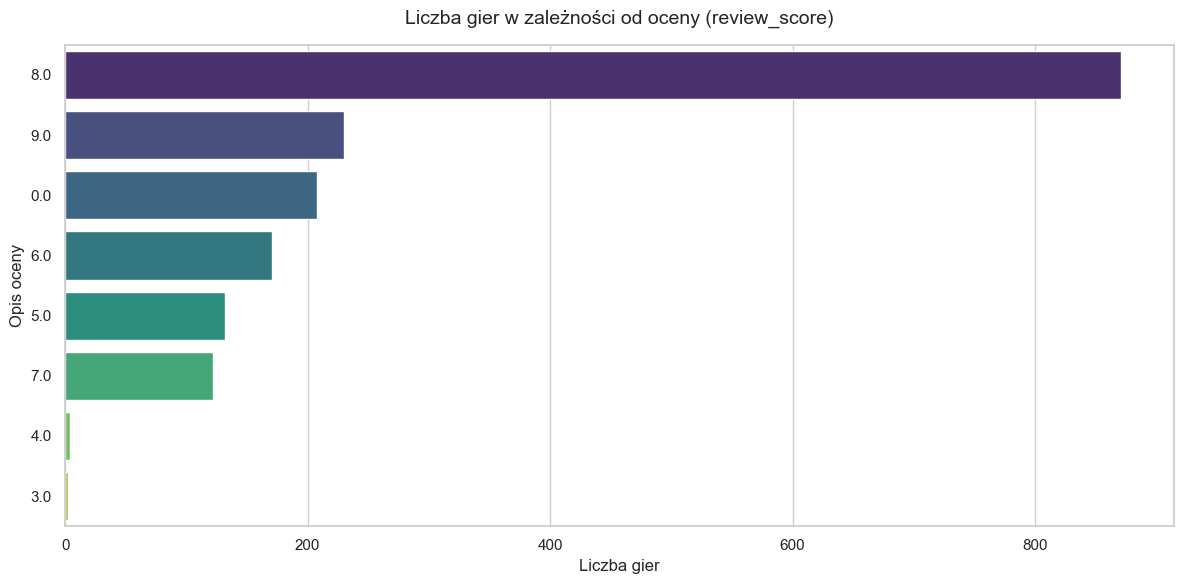

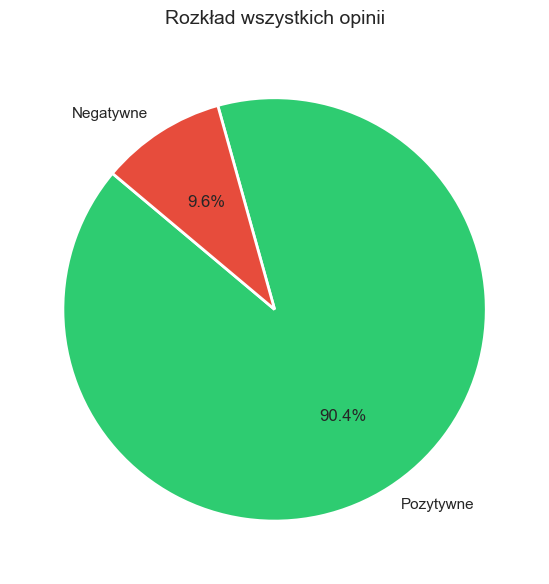

In [152]:
df_steam_stats = pd.read_csv(stats_path)

# Ustawienie estetycznego stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Zakładamy, że Twój DataFrame nazywa się 'df'

# ==========================================
# WYKRES 1: Liczba gier dla każdego review_score_desc
# ==========================================
plt.figure()
# Sortujemy wartości, żeby wykres słupkowy wyglądał porządnie
order = df_steam_stats['review_score'].value_counts().index

sns.countplot(data=df_steam_stats, y='review_score', order=order, palette='viridis')
plt.title('Liczba gier w zależności od oceny (review_score)', fontsize=14, pad=15)
plt.xlabel('Liczba gier', fontsize=12)
plt.ylabel('Opis oceny', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# WYKRES 2: Całkowita ilość opinii pozytywnych vs negatywnych
# ==========================================
plt.figure(figsize=(8, 6))
# Sumujemy wszystkie opinie z całego zestawu danych
total_positive = df_steam_stats['total_positive'].sum()
total_negative = df_steam_stats['total_negative'].sum()

labels = ['Pozytywne', 'Negatywne']
sizes = [total_positive, total_negative]
colors = ['#2ecc71', '#e74c3c'] # zielony i czerwony

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Rozkład wszystkich opinii', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

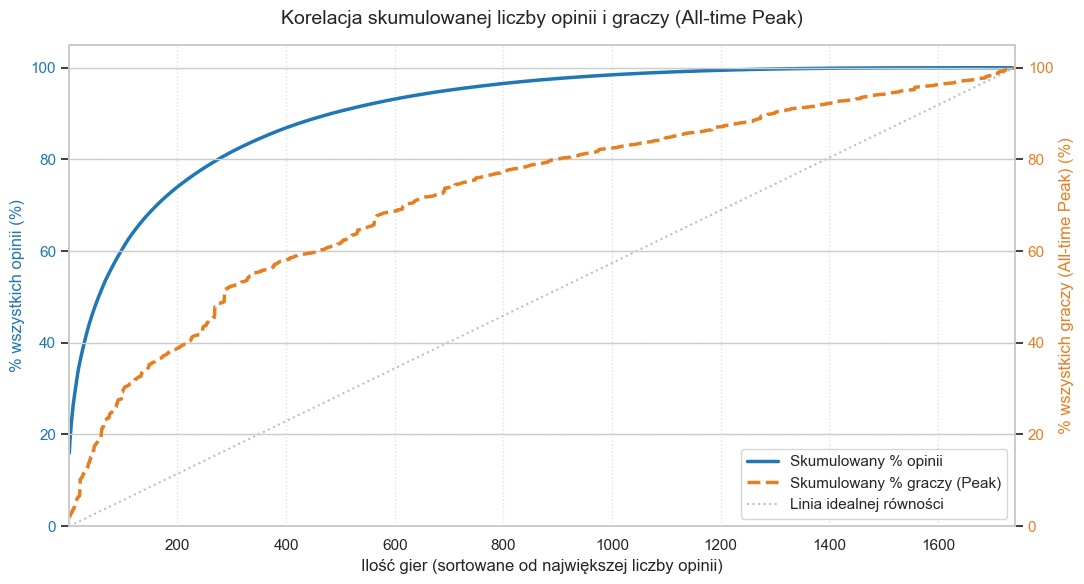

In [151]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Przygotowanie danych (sortujemy niezmiennie według total_reviews)
df_sorted = df_steam_stats.sort_values(by='total_reviews', ascending=False).reset_index(drop=True)

# 2. Obliczamy skumulowany % dla opinii
df_sorted['cumulative_reviews'] = df_sorted['total_reviews'].cumsum()
df_sorted['pct_reviews'] = (df_sorted['cumulative_reviews'] / df_sorted['total_reviews'].sum()) * 100

# 3. Obliczamy skumulowany % dla graczy (all-time_peak)
df_sorted['cumulative_peak'] = df_sorted['all-time_peak'].cumsum()
df_sorted['pct_peak'] = (df_sorted['cumulative_peak'] / df_sorted['all-time_peak'].sum()) * 100

# 4. Oś X - liczba gier
df_sorted['game_count'] = df_sorted.index + 1

# ==========================================
# WIZUALIZACJA: Dwie krzywe skumulowane na jednym wykresie
# ==========================================
fig, ax1 = plt.subplots(figsize=(11, 6))

# --- Pierwsza krzywa: Skumulowane Opinie (lewa oś Y) ---
line1 = ax1.plot(df_sorted['game_count'], df_sorted['pct_reviews'], 
                 color='#1f77b4', linewidth=2.5, label='Skumulowany % opinii')
ax1.set_xlabel('Ilość gier (sortowane od największej liczby opinii)', fontsize=12)
ax1.set_ylabel('% wszystkich opinii (%)', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_ylim(0, 105)

# --- Druga krzywa: Skumulowani Gracze (prawa oś Y) ---
ax2 = ax1.twinx()  # Tworzymy bliźniaczą oś Y
line2 = ax2.plot(df_sorted['game_count'], df_sorted['pct_peak'], 
                 color='#e67e22', linewidth=2.5, linestyle='--', label='Skumulowany % graczy (Peak)')
ax2.set_ylabel('% wszystkich graczy (All-time Peak) (%)', color='#e67e22', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#e67e22')
ax2.set_ylim(0, 105)

# --- Linia odniesienia (idealna równość) ---
line3 = ax1.plot([1, df_sorted['game_count'].max()], [0, 100], 
                 color='gray', linestyle=':', alpha=0.5, label='Linia idealnej równości')

# Połączenie legend z obu osi w jedno okienko
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', fontsize=11)

plt.title('Korelacja skumulowanej liczby opinii i graczy (All-time Peak)', fontsize=14, pad=15)
ax1.set_xlim(1, df_sorted['game_count'].max())
ax1.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Wygląda na to że liderzy mają więcej opinii niż graczy. Może to wynika z tego, że bardzo dużo osób próbuje topowe gry i wystawia im opinie, a bardziej niszowe gry przyciągają mniejsze grono gracyz? innymi słowy, w CS:GO ciągle grają nowi gracze, wielu z nich wystawia opinie. W mniejsze gry gra mniejsza bardziej stabilna garstka osób, co oznacza, że all-time peak, jest znacznie bliżej ilości zakupionych kopii gier, względem największych graczy?

C:\Users\karol\AppData\Local\Temp\ipykernel_18452\3418502369.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


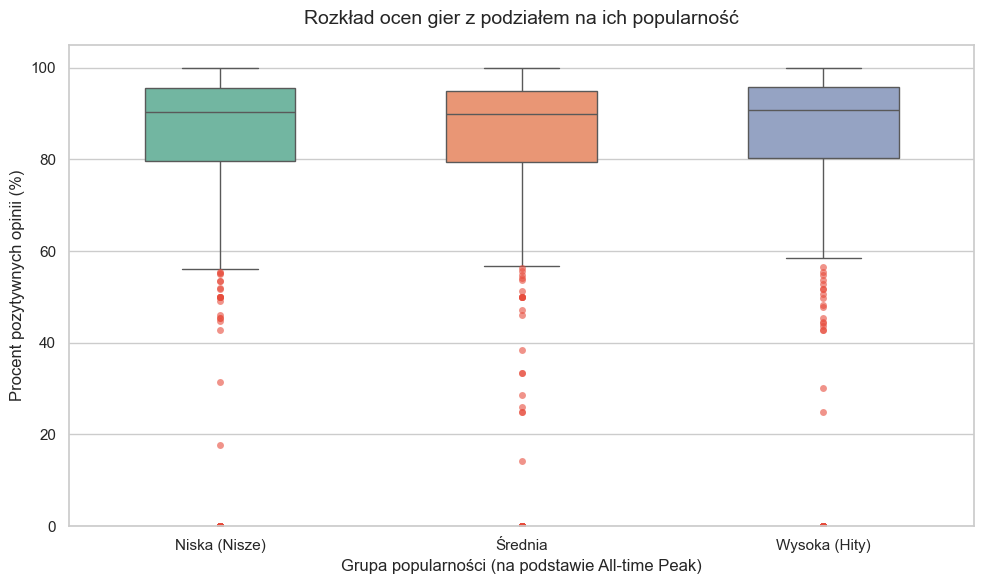

In [158]:
# 1. Przygotowanie danych: dzielimy gry na 3 równe grupy pod kątem popularności (all-time_peak)
# qcut automatycznie podzieli dane na tercyle (3 równe ilościowo grupy)
df_clean = df_steam_stats.copy()
df_clean['Popularność gier'] = pd.qcut(
    df_clean['all-time_peak'], 
    q=3, 
    labels=['Niska (Nisze)', 'Średnia', 'Wysoka (Hity)']
)

# Ustawienie stylu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# ==========================================
# WIZUALIZACJA: Wykres pudełkowy (rozpad na anomalie i wąsy)
# ==========================================
sns.boxplot(
    data=df_clean, 
    x='Popularność gier', 
    y='percent_positive', 
    palette='Set2',
    width=0.5,
    flierprops={'marker': 'o', 'markerfacecolor': '#e74c3c', 'markeredgecolor': 'none', 'alpha': 0.6, 'markersize': 5}
)

# Tytuły i opisy
plt.title('Rozkład ocen gier z podziałem na ich popularność', fontsize=14, pad=15)
plt.xlabel('Grupa popularności (na podstawie All-time Peak)', fontsize=12)
plt.ylabel('Procent pozytywnych opinii (%)', fontsize=12)

plt.ylim(0, 105) # Pełen zakres procentowy
plt.tight_layout()
plt.show()

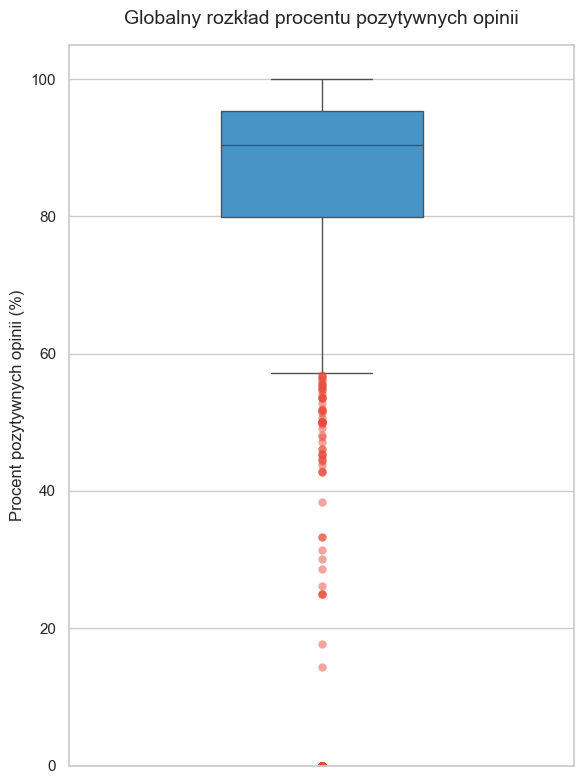

In [162]:
# Ustawienie stylu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 8))

# ==========================================
# WIZUALIZACJA: Pojedynczy wykres pudełkowy dla całego df
# ==========================================
sns.boxplot(
    data=df_steam_stats, 
    y='percent_positive', 
    color='#3498db',
    width=0.4,
    # Konfiguracja kropek oznaczających anomalie (outliery)
    flierprops={
        'marker': 'o', 
        'markerfacecolor': '#e74c3c', 
        'markeredgecolor': 'none', 
        'alpha': 0.5, 
        'markersize': 6
    }
)

# Tytuły i opisy osi
plt.title('Globalny rozkład procentu pozytywnych opinii', fontsize=14, pad=15)
plt.ylabel('Procent pozytywnych opinii (%)', fontsize=12)

# Usuwamy etykiety osi X, bo mamy tylko jedną kategorię (cały zbiór)
plt.xticks([]) 

plt.ylim(0, 105) # Pełen zakres procentowy od 0 do 100% z małym zapasem
plt.tight_layout()
plt.show()

In [163]:
print(df_steam_stats.sort_values('percent_positive'))

      steam_id                                   name  all-time_peak  \
1056   2336220                          Feed The Cups          11413   
451    3495810                            Wet Passion          37733   
1137   2103130                       Matchmaking Inc.          10109   
757    3165720                    Fellowship Playtest          18609   
1722   2124680                        Winning Post 10           5115   
...        ...                                    ...            ...   
1252   3101040  Magical Girl Witch Trials (魔法少女ノ魔女裁判)           8653   
1303   1353230                    Bomb Rush Cyberfunk           8174   
271    2384580              DYNASTY WARRIORS: ORIGINS          69483   
1298   3213850           gogh: Focus with Your Avatar           8236   
1335    488210                       JDM Tuner Racing           7970   

      total_reviews  total_positive  total_negative  percent_positive  \
1056            0.0             0.0             0.0           

In [164]:
# 1. Tworzymy nową kolumnę z przypisanym decylem (od 1 do 10)
# 'labels=False' przypisze numery 0-9, więc dodajemy 1, aby mieć przejrzyste decyle 1-10
df_steam_stats['decile'] = pd.qcut(df_steam_stats['percent_positive'], q=10, labels=False, duplicates='drop') + 1

# 2. Agregujemy dane obliczając średnie dla poszczególnych kolumn
summary_table = df_steam_stats.groupby('decile').agg(
    range_min=('percent_positive', 'min'),
    range_max=('percent_positive', 'max'),
    avg_peak=('all-time_peak', 'mean'),
    avg_total_reviews=('total_reviews', 'mean'),
    avg_positive=('total_positive', 'mean'),
    avg_negative=('total_negative', 'mean')
).reset_index()

# 3. Zaokrąglamy wyniki do liczb całkowitych dla lepszej czytelności
columns_to_round = ['avg_peak', 'avg_total_reviews', 'avg_positive', 'avg_negative']
summary_table[columns_to_round] = summary_table[columns_to_round].round(0).astype(int)

# 4. Formatujemy kolumnę z zakresem procentowym dla estetyki
summary_table['Przedział ocen (%)'] = summary_table.apply(
    lambda row: f"{row['range_min']:.1f}% - {row['range_max']:.1f}%", axis=1
)

# Selekcja i zmiana nazw kolumn do finalnego wyświetlenia
final_table = summary_table[[
    'decile', 'Przedział ocen (%)', 'avg_peak', 'avg_total_reviews', 'avg_positive', 'avg_negative'
]].rename(columns={
    'decile': 'Decyl',
    'avg_peak': 'Średni Peak Graczy',
    'avg_total_reviews': 'Średnia ilość opinii',
    'avg_positive': 'Średnie opinie (+)',
    'avg_negative': 'Średnie opinie (-)'
})

# Wyświetlenie tabeli
print(final_table.to_string(index=False))

 Decyl Przedział ocen (%)  Średni Peak Graczy  Średnia ilość opinii  Średnie opinie (+)  Średnie opinie (-)
   1.0       0.0% - 61.9%               39629                   247                 133                 114
   2.0      61.9% - 76.2%               60910                   691                 484                 207
   3.0      76.4% - 82.7%               70030                  1082                 863                 219
   4.0      82.7% - 87.2%               54581                  4150                3589                 561
   5.0      87.2% - 90.4%               44624                  1176                1048                 129
   6.0      90.5% - 92.7%               56485                  1893                1733                 160
   7.0      92.7% - 94.5%               57463                  2223                2081                 142
   8.0      94.6% - 96.2%               57101                  1867                1782                  85
   9.0      96.3% - 97.8%   

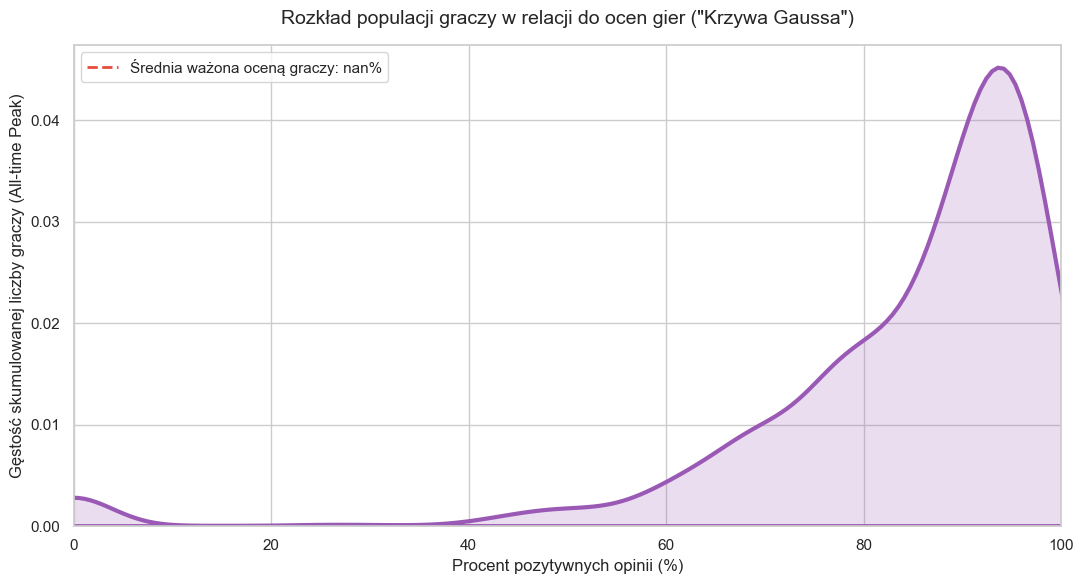

In [165]:
# Ustawienie stylu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

# ==========================================
# WIZUALIZACJA: "Krzywa Gaussa" ważona liczbą graczy
# ==========================================

# Rysujemy wygładzoną krzywą gęstości (KDE)
# Parametr 'weights' sprawia, że wysokość krzywej zależy od liczby graczy (all-time_peak)
sns.kdeplot(
    data=df_steam_stats, 
    x='percent_positive', 
    weights='all-time_peak', 
    bw_adjust=0.6,          # Subtelne wygładzenie linii, by przypominała dzwon
    color='#9b59b6', 
    linewidth=3, 
    fill=True, 
    alpha=0.2
)

# Dodanie pionowej linii oznaczającej średnią ważoną (środek ciężkości rynku)
srednia_wazona = np.average(df_steam_stats['percent_positive'], weights=df_steam_stats['all-time_peak'])
plt.axvline(srednia_wazona, color='#e74c3c', linestyle='--', linewidth=2, 
            label=f'Średnia ważona oceną graczy: {srednia_wazona:.1f}%')

# Tytuły i opisy osi
plt.title('Rozkład populacji graczy w relacji do ocen gier ("Krzywa Gaussa")', fontsize=14, pad=15)
plt.xlabel('Procent pozytywnych opinii (%)', fontsize=12)
plt.ylabel('Gęstość skumulowanej liczby graczy (All-time Peak)', fontsize=12)

plt.xlim(0, 100)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

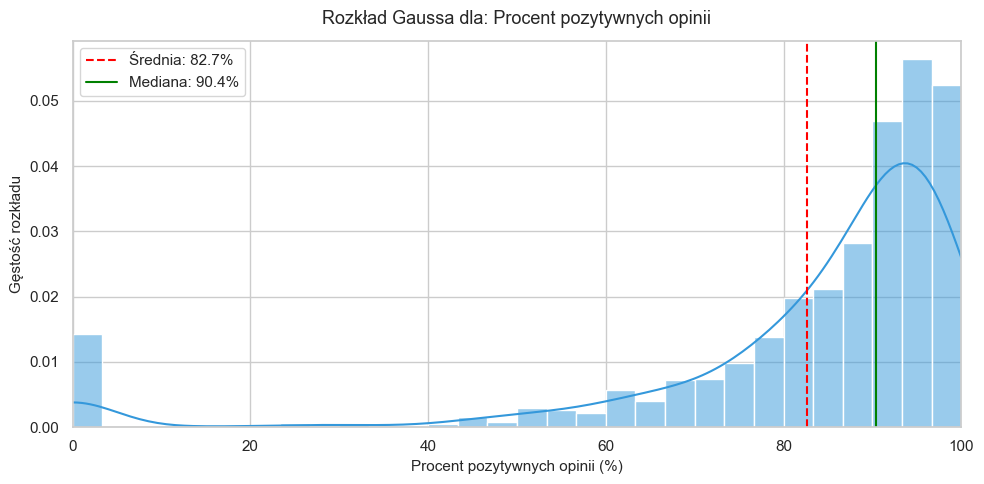

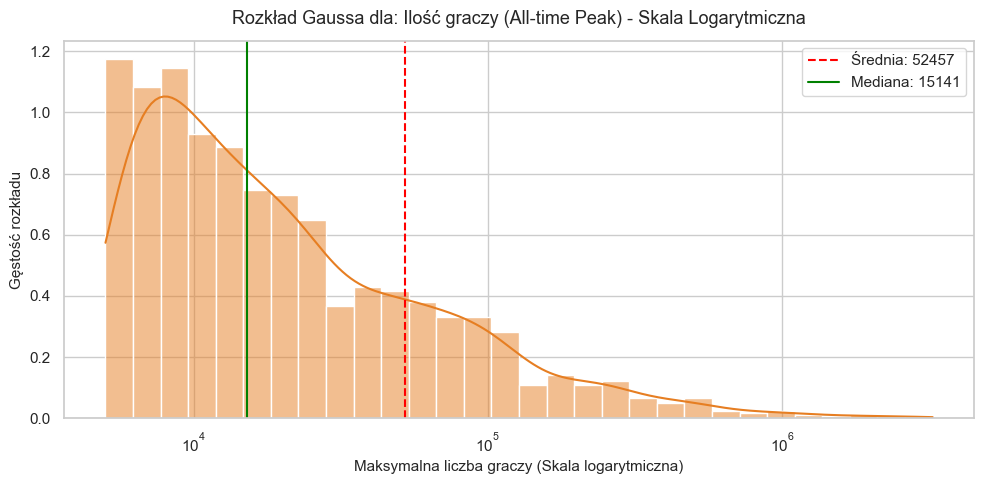

c:\Users\karol\repos\dsai-final-project\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


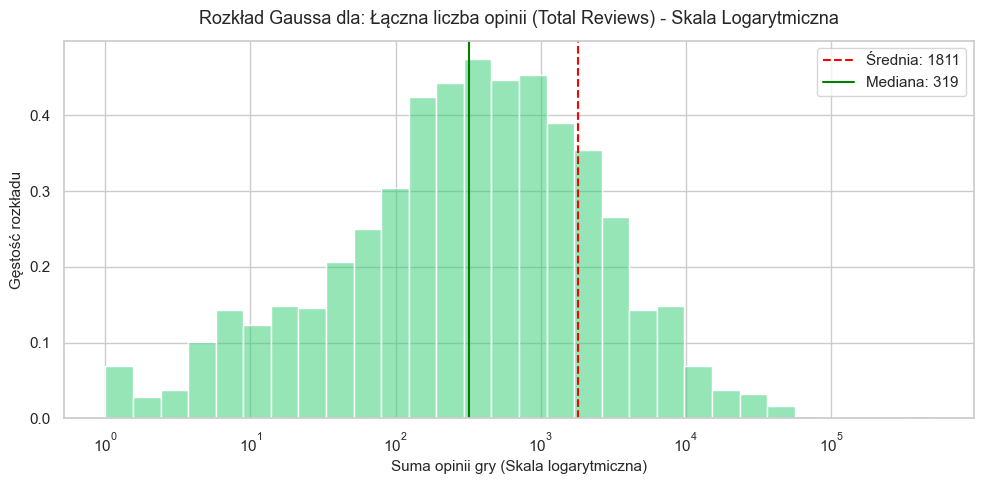

In [168]:

# Ustawienie globalnego stylu
sns.set_theme(style="whitegrid")

# ==========================================
# WYKRES 1: Klasyczny rozkład procentu pozytywnych opinii
# ==========================================
plt.figure(figsize=(10, 5))
sns.histplot(data=df_steam_stats, x='percent_positive', kde=True, stat="density", color='#3498db', bins=30)

# Dodanie linii oznaczającej średnią i medianę
plt.axvline(df_steam_stats['percent_positive'].mean(), color='red', linestyle='--', label=f"Średnia: {df_steam_stats['percent_positive'].mean():.1f}%")
plt.axvline(df_steam_stats['percent_positive'].median(), color='green', linestyle='-', label=f"Mediana: {df_steam_stats['percent_positive'].median():.1f}%")

plt.title('Rozkład Gaussa dla: Procent pozytywnych opinii', fontsize=13, pad=12)
plt.xlabel('Procent pozytywnych opinii (%)', fontsize=11)
plt.ylabel('Gęstość rozkładu', fontsize=11)
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# WYKRES 2: Rozkład dla ilości graczy (All-time Peak) - Skala Logarytmiczna
# ==========================================
plt.figure(figsize=(10, 5))
# Logarytmujemy dane dla osi X, aby uzyskać kształt dzwonu
sns.histplot(data=df_steam_stats, x='all-time_peak', kde=True, stat="density", color='#e67e22', log_scale=True, bins=30)

# Średnia i mediana w skali logarytmicznej
plt.axvline(df_steam_stats['all-time_peak'].mean(), color='red', linestyle='--', label=f"Średnia: {int(df_steam_stats['all-time_peak'].mean())}")
plt.axvline(df_steam_stats['all-time_peak'].median(), color='green', linestyle='-', label=f"Mediana: {int(df_steam_stats['all-time_peak'].median())}")

plt.title('Rozkład Gaussa dla: Ilość graczy (All-time Peak) - Skala Logarytmiczna', fontsize=13, pad=12)
plt.xlabel('Maksymalna liczba graczy (Skala logarytmiczna)', fontsize=11)
plt.ylabel('Gęstość rozkładu', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# WYKRES 3: Rozkład dla łącznej liczby opinii (Total Reviews) - Skala Logarytmiczna
# ==========================================
plt.figure(figsize=(10, 5))
# Logarytmujemy dane dla osi X, aby uzyskać kształt dzwonu
sns.histplot(data=df_steam_stats, x='total_reviews', kde=True, stat="density", color='#2ecc71', log_scale=True, bins=30)

# Średnia i mediana w skali logarytmicznej
plt.axvline(df_steam_stats['total_reviews'].mean(), color='red', linestyle='--', label=f"Średnia: {int(df_steam_stats['total_reviews'].mean())}")
plt.axvline(df_steam_stats['total_reviews'].median(), color='green', linestyle='-', label=f"Mediana: {int(df_steam_stats['total_reviews'].median())}")

plt.title('Rozkład Gaussa dla: Łączna liczba opinii (Total Reviews) - Skala Logarytmiczna', fontsize=13, pad=12)
plt.xlabel('Suma opinii gry (Skala logarytmiczna)', fontsize=11)
plt.ylabel('Gęstość rozkładu', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()